

1.   **Ehsan Arshad (FA23-BBD-036)**
2.   **Umair Ali (FA23-BBD-170)**


1.   **Abdullah Khan (FA23-BBD-006)**








In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [1]:
import os

base = '/content/drive/MyDrive/casting_data'

folders = {
    'train/def_front': f'{base}/train/def_front',
    'train/ok_front' : f'{base}/train/ok_front',
    'test/def_front' : f'{base}/test/def_front',
    'test/ok_front'  : f'{base}/test/ok_front',
}

print(" Checking your dataset:\n")
for name, path in folders.items():
    if os.path.exists(path):
        count = len(os.listdir(path))
        print(f"    {name}:  {count} images")
    else:
        print(f"    {name}:  NOT FOUND")

 Checking your dataset:

    train/def_front:  NOT FOUND
    train/ok_front:  NOT FOUND
    test/def_front:  NOT FOUND
    test/ok_front:  NOT FOUND


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import os

print(" All libraries imported!")

 All libraries imported!


In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")

if torch.cuda.is_available():
    print(f" GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print(" GPU not found! Go to Runtime → Change runtime type → T4 GPU")

 Using device: cuda
 GPU Name: Tesla T4


In [21]:
BASE_DIR  = '/content/drive/MyDrive/casting_data'
TRAIN_DIR = BASE_DIR + '/train'
TEST_DIR  = BASE_DIR + '/test'

print(f" Train folder: {TRAIN_DIR}")
print(f" Test folder:  {TEST_DIR}")

 Train folder: /content/drive/MyDrive/casting_data/train
 Test folder:  /content/drive/MyDrive/casting_data/test


 Image mode:  RGB
 Image size:  (300, 300)


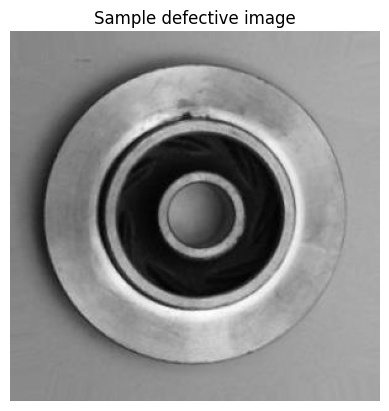

In [20]:
import os

#Opening 1 sample and checking its properties
sample_path = os.path.join(TRAIN_DIR, 'def_front',
              os.listdir(os.path.join(TRAIN_DIR, 'def_front'))[0])

img = Image.open(sample_path)
print(f" Image mode:  {img.mode}")
print(f" Image size:  {img.size}")

plt.imshow(img)
plt.title("Sample defective image")
plt.axis('off')
plt.show()

In [13]:
img = Image.open(sample_path)
print(f"Image mode: {img.mode}")
print(f"Image size: {img.size}")

Image mode: RGB
Image size: (300, 300)


In [17]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std =[0.5, 0.5, 0.5]
    )
])

print(" Transforms defined!")

 Transforms defined!


In [18]:
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=transform)
test_dataset  = datasets.ImageFolder(root=TEST_DIR,  transform=transform)

print(f" Classes found:    {train_dataset.classes}")
print(f" Class indices:    {train_dataset.class_to_idx}")
print(f" Training images:  {len(train_dataset)}")
print(f" Testing images:   {len(test_dataset)}")

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\n DataLoaders ready! Batch size: {BATCH_SIZE}")

 Classes found:    ['def_front', 'ok_front']
 Class indices:    {'def_front': 0, 'ok_front': 1}
 Training images:  6633
 Testing images:   715

 DataLoaders ready! Batch size: 32


In [19]:
class CDD(nn.Module):
    def __init__(self):
        super(CDD, self).__init__()

        # Conv Block 1: 3 input channels → 32 feature maps
        self.conv1 = nn.Conv2d(in_channels=3,  out_channels=32,  kernel_size=3, padding=1, stride=1)
        self.bn1   = nn.BatchNorm2d(32)

        # Conv Block 2: 32 → 64 feature maps
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64,  kernel_size=3, padding=1, stride=1)
        self.bn2   = nn.BatchNorm2d(64)

        # Conv Block 3: 64 → 128 feature maps
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1, stride=1)
        self.bn3   = nn.BatchNorm2d(128)

        # MaxPooling (halves image size each time)
        self.pool    = nn.MaxPool2d(kernel_size=2, stride=2)

        # Dropout (prevents overfitting)
        self.dropout = nn.Dropout(p=0.5)

        # Fully Connected Layers
        # After 3 pools: 128x128 → 64 → 32 → 16, with 128 channels
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, 2)   # 2 output classes

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 128→64
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 64→32
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 32→16
        x = x.view(x.size(0), -1)                       # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


model = CDD().to(device)
print(model)
print(f"\n Model created on: {device}")

CDD(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)

 Model created on: cuda


In [25]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 15

# Store history for charts
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

print(" Training started...\n")

for epoch in range(EPOCHS):

    # ---- TRAINING ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100. * correct / total

    #  VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            val_loss      += loss.item()
            _, predicted   = outputs.max(1)
            val_total     += labels.size(0)
            val_correct   += predicted.eq(labels).sum().item()

    val_loss = val_loss / len(test_loader)
    val_acc  = 100. * val_correct / val_total

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1:2d}/{EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  |  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%")

print("\n Training complete!")

 Training started...

Epoch [ 1/15]  Train Loss: 0.6372  Train Acc: 82.92%  |  Val Loss: 0.2217  Val Acc: 90.07%
Epoch [ 2/15]  Train Loss: 0.2519  Train Acc: 87.83%  |  Val Loss: 0.2206  Val Acc: 90.21%
Epoch [ 3/15]  Train Loss: 0.2298  Train Acc: 88.56%  |  Val Loss: 0.1162  Val Acc: 94.55%
Epoch [ 4/15]  Train Loss: 0.1986  Train Acc: 90.86%  |  Val Loss: 0.1105  Val Acc: 95.52%
Epoch [ 5/15]  Train Loss: 0.2631  Train Acc: 87.91%  |  Val Loss: 0.1171  Val Acc: 95.10%
Epoch [ 6/15]  Train Loss: 0.1776  Train Acc: 91.72%  |  Val Loss: 0.0646  Val Acc: 96.92%
Epoch [ 7/15]  Train Loss: 0.1429  Train Acc: 93.32%  |  Val Loss: 0.0434  Val Acc: 97.90%
Epoch [ 8/15]  Train Loss: 0.1325  Train Acc: 93.47%  |  Val Loss: 0.0479  Val Acc: 97.62%
Epoch [ 9/15]  Train Loss: 0.1261  Train Acc: 94.04%  |  Val Loss: 0.0521  Val Acc: 97.48%
Epoch [10/15]  Train Loss: 0.1175  Train Acc: 94.26%  |  Val Loss: 0.0409  Val Acc: 98.46%
Epoch [11/15]  Train Loss: 0.1129  Train Acc: 94.68%  |  Val Loss: 0

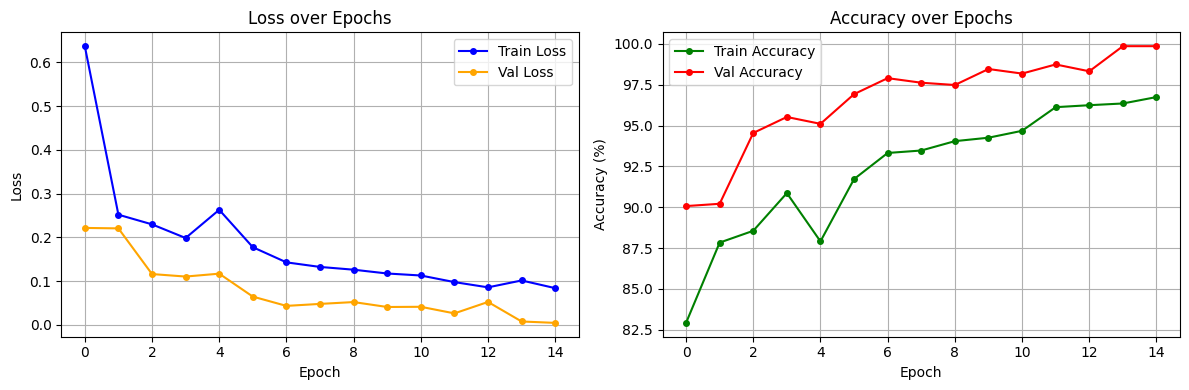

 Charts saved to Google Drive!


In [26]:
plt.figure(figsize=(12, 4))

# Loss chart
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss',  color='blue',   marker='o', markersize=4)
plt.plot(val_losses,   label='Val Loss',    color='orange', marker='o', markersize=4)
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy chart
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy', color='green', marker='o', markersize=4)
plt.plot(val_accs,   label='Val Accuracy',   color='red',   marker='o', markersize=4)
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_charts.png', dpi=150)
plt.show()
print(" Charts saved to Google Drive!")

<Figure size 600x500 with 0 Axes>

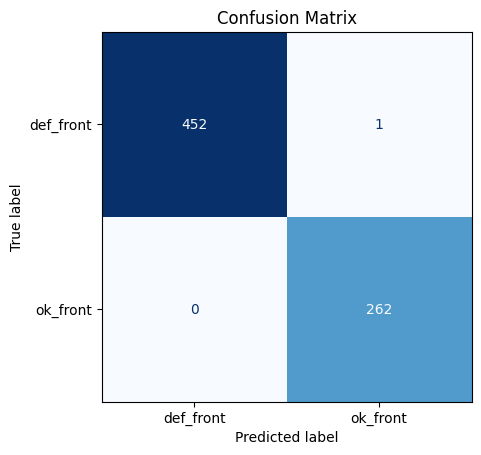


 Classification Report:
              precision    recall  f1-score   support

   def_front       1.00      1.00      1.00       453
    ok_front       1.00      1.00      1.00       262

    accuracy                           1.00       715
   macro avg       1.00      1.00      1.00       715
weighted avg       1.00      1.00      1.00       715



In [27]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images     = images.to(device)
        outputs    = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = train_dataset.classes  # ['def_front', 'ok_front']

# --- Confusion Matrix ---
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
plt.show()

# --- Classification Report ---
print("\n Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [29]:
MODEL_PATH = '/content/drive/MyDrive/CDD_model.pth'
torch.save(model.state_dict(), MODEL_PATH)
print(f" Model saved to: {MODEL_PATH}")

 Model saved to: /content/drive/MyDrive/CDD_model.pth


 Model loaded successfully!

 Prediction: def_front


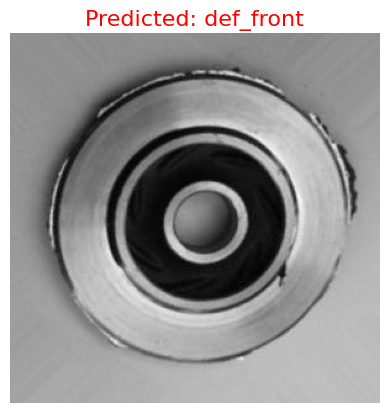

In [30]:
# Load saved model fresh
loaded_model = CDD().to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
loaded_model.eval()
print(" Model loaded successfully!")

# Pick one defective test image
test_img_path = os.path.join(TEST_DIR, 'def_front',
                os.listdir(os.path.join(TEST_DIR, 'def_front'))[0])

# Prepare image
img        = Image.open(test_img_path).convert('RGB')
img_tensor = transform(img).unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    output     = loaded_model(img_tensor)
    _, pred    = output.max(1)

label = train_dataset.classes[pred.item()]

# Show result
print(f"\n Prediction: {label}")

plt.imshow(img)
plt.title(f"Predicted: {label}",
          fontsize=16,
          color='red' if 'def' in label else 'green')
plt.axis('off')
plt.show()

 Prediction: ok_front


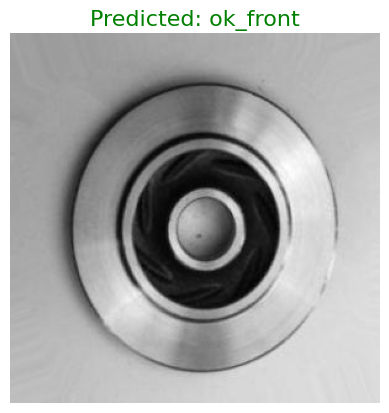

In [32]:
# Pick one OK test image
ok_img_path = os.path.join(TEST_DIR, 'ok_front',
              os.listdir(os.path.join(TEST_DIR, 'ok_front'))[0])

img2        = Image.open(ok_img_path).convert('RGB')
img_tensor2 = transform(img2).unsqueeze(0).to(device)

with torch.no_grad():
    output2   = loaded_model(img_tensor2)
    _, pred2  = output2.max(1)

label2 = train_dataset.classes[pred2.item()]

print(f" Prediction: {label2}")

plt.imshow(img2)
plt.title(f"Predicted: {label2}",
          fontsize=16,
          color='red' if 'def' in label2 else 'green')
plt.axis('off')
plt.show()